# Stellar Mergers: Metallicity Sweep

In [1]:
# instead of looking at rlof_df, why don't i look at system parameters? 
# wouldnt this more accurately tell me all the non-common envelope mergers, i.e., from sources other than rlof?
# something like: merged_seeds = set(sys_df[sys_df["Merger"] == 1]["SEED"].values) non_ce_seeds = merged_seeds - ce_seeds_all

# answer: 
# from running the code below, we get
# with h5py.File('./COMPAS_Output/Compas_Output.h5', 'r') as f:
#    print("System_parameters columns:")
#    print(list(f["BSE_System_Parameters"].keys()))

# System_parameters columns:
#      ['CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity@ZAMS', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 
# 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega@ZAMS(1)', 
# 'Omega@ZAMS(2)', 'PO_CE_Alpha', 'PO_CE_Formalism', 'PO_LBV_Factor', 'PO_Sigma_Kick_CCSN_BH', 'PO_Sigma_Kick_CCSN_NS', 
# 'PO_Sigma_Kick_ECSN', 'PO_Sigma_Kick_USSN', 'PO_WR_Factor', 'Record_Type', 'SEED', 'SN_Kick_Magnitude_Random_Number(1)', '
# SN_Kick_Magnitude_Random_Number(2)', 'SemiMajorAxis@ZAMS', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Stellar_Type@ZAMS(1)', 
# 'Stellar_Type@ZAMS(2)', 'Unbound']

# BSE_System_Parameters has no donor-type-at-merger column, so you lose per-case classification for non-CE mergers

In [2]:
import itertools
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import h5py
import pandas as pd
import yaml
from IPython.display import display

import time

In [3]:
pd.set_option('display.max_columns', None)

## Helper functions

In [4]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def save_yaml(obj, path):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)

def set_compas_option(cfg, key, value):
    """Insert a key/value into the correct yaml block based on Python type."""
    if isinstance(value, bool):
        cfg.setdefault("booleanChoices", {})[key] = value
    elif isinstance(value, (int, float)):
        cfg.setdefault("numericalChoices", {})[key] = value
    elif isinstance(value, str):
        cfg.setdefault("stringChoices", {})[key] = value
    else:
        raise TypeError(f"unsupported value type for {key}: {type(value)}")

def load_compas_group(h5_path, group_name):
    """Load a COMPAS HDF5 output group into a pandas DataFrame."""
    with h5py.File(h5_path, 'r') as f:
        if group_name not in f:
            return pd.DataFrame()
        group = f[group_name]
        data = {col: group[col][:] for col in group.keys()}
    return pd.DataFrame(data)

In [5]:
BASE_CONFIG = Path("../compas_config.yaml")

# Z and alpha_CE values to sweep
METALLICITIES = [0.02, 0.002, 0.0002]
ALPHA_VALUES  = [0.5, 1.0, 2.0]          
N_VALUES      = [1_000]  # Holding off on 10,000 for now

In [6]:
def run_metallicity_case(metallicity, n_systems, seed, alpha_ce=1.0, base_config=BASE_CONFIG):
    run_name = f"met_{metallicity:.4f}__n_{n_systems}__alpha_{alpha_ce}"

    cfg = load_yaml(base_config)
    set_compas_option(cfg, "--random-seed",              int(seed))
    set_compas_option(cfg, "--number-of-systems",        int(n_systems))
    set_compas_option(cfg, "--metallicity",              float(metallicity))
    set_compas_option(cfg, "--common-envelope-alpha",    float(alpha_ce))
    set_compas_option(cfg, "--logfile-type",             "HDF5")

    cfg_path = Path(f"config_{run_name}.yaml")
    save_yaml(cfg, cfg_path)

    # keep track of existing COMPAS_Output dirs to know which ones were not created by the current simulation 
    # (since they must have been created prior)
    before = set(Path(".").glob("COMPAS_Output*"))
    
    # run the COMPAS simulation and check if successful
    proc = subprocess.run(
        ["compas_run_submit", str(cfg_path)],
        capture_output=True, text=True,
    )
    if proc.returncode != 0:
        print(f"FAILED [{run_name}]:\n{proc.stderr}")
        return None

    # delete temporary config file
    cfg_path.unlink()

    # keep track of the new COMPAS_Output dirs that were created: these are the ones whose information we care about
    after = set(Path(".").glob("COMPAS_Output*"))
    new_dirs = after - before
    if len(new_dirs) != 1:
        raise RuntimeError(f"Expected exactly one new COMPAS_Output directory, found {len(new_dirs)}: {new_dirs}")
    
    new_dir  = list(new_dirs)[0]
    h5_files = list(new_dir.glob("**/*.h5"))
    if len(h5_files) != 1:
        raise RuntimeError(f"Expected exactly one h5 file in the COMPAS_Output directory, found {len(h5_files)}: {h5_files}")

    return h5_files[0]

# Stellar type legend (COMPAS)
-  0  = MS (< 0.7 Msun)
-  1  = MS (>= 0.7 Msun)
-  2  = Hertzsprung Gap 
-  3  = First Giant Branch
-  4  = Core He Burning
-  5  = Early AGB
-  6  = TPAGB
-  7  = He MS
-  8  = He HG
-  9  = He GB
- 10  = He WD
- 11 = CO WD  
- 12 = ONe WD  
- 13 = NS  
- 14 = BH  
- 15 = Massless remnant

Compact objects (CO) are types >= 10, so from this point on we EXCLUDE them to keep only stellar mergers.

In [7]:
STELLAR_TYPE_MAX = 9

In [8]:
def extract_case_counts(h5_path, n_systems):
    """
    Return per-MT-case merger counts, filtering out compact object cases.

    Left plot:  bar = total mergers / N per case, hatch = CE mergers / N
    Right plot: bar = CE episodes / N per case,   hatch = CE mergers / N

    Case classification:
    CE mergers: classified by donor stellar type at CE onset from BSE_Common_Envelopes.
    Non-CE mergers: classified by donor stellar type at RLOF onset from BSE_RLOF,
            excluding any SEED already counted as a CE merger.
    """

    sys_df = load_compas_group(str(h5_path), "BSE_System_Parameters")  # one row per simulated binary
    
    # actual number of systems that ran by counting unique SEEDs in the system parameters table,
    # each binary system in the simulation is assigned a unique integer SEED at initialization
    # (in successful simulation case, this should equal n_systems)
    n_total = int(sys_df["SEED"].nunique()) if "SEED" in sys_df.columns else n_systems

    # ------------------------------------------------------------------ #
    # 1. Filter CE table to stellar-only episodes                        #
    #    (exclude any CE where either star is a compact object)          #
    # ------------------------------------------------------------------ #

    ce_df  = load_compas_group(str(h5_path), "BSE_Common_Envelopes")   # one row per CE episode (i.e., a system that underwent two CEs will appear twice here)
    if ce_df.empty:
        raise RuntimeError(f"BSE_Common_Envelopes is empty in {str(h5_path)}")
    
    ce = ce_df.copy()
    stellar_ok = (
        # Stellar_Type(1)<CE and Stellar_Type(2)<CE are the stellar types of both stars at the 
        # moment the CE episode begins: <CE suffix is COMPAS notation for "immediately before CE event."
        (ce["Stellar_Type(1)<CE"] <= STELLAR_TYPE_MAX) &
        (ce["Stellar_Type(2)<CE"] <= STELLAR_TYPE_MAX)
    )

    # boolean mask stellar_ok keeps only rows where both stars are stellar at CE onset 
    ce = ce[stellar_ok]

    # RLOF(1) == 1 means star 1 is filling its Roche lobe, making it the donor. If star 1 
    # is the donor, donor_type takes star 1's type; otherwise it takes star 2's type. 
    # This gives you the evolutionary state of the mass-transferring star for every CE episode.
    donor_type = np.where(
        ce["RLOF(1)"] == 1,
        ce["Stellar_Type(1)<CE"],
        ce["Stellar_Type(2)<CE"],
    )

    case_a_mask = (donor_type == 1)   # MS donor (>= 0.7 Msun); if we wanted to include < 0.7 MSun, change to donor_type <= 1
    case_b_mask = (donor_type == 2)   # Hertzsprung Gap donor
    case_c_mask = (donor_type  > 2)   # Giant branch or beyond (FGB, CHeB, AGB, He-star)
    merger_mask = (ce["Merger"] == 1) # flags CE episodes that ended in merger rather than envelope ejection

    # CE episodes per case (right plot bar heights)
    total_ce_a = int(case_a_mask.sum())
    total_ce_b = int(case_b_mask.sum())
    total_ce_c = int(case_c_mask.sum())

    # CE mergers per case (hatch on both plots)
    ce_merger_a = int((case_a_mask & merger_mask).sum())
    ce_merger_b = int((case_b_mask & merger_mask).sum())
    ce_merger_c = int((case_c_mask & merger_mask).sum())

    # ------------------------------------------------------------------ #
    # 2. Non-CE mergers from BSE_RLOF                                    #
    #    This table has stellar types at time of event, so we can apply  #
    #    the same stellar-only filter as section 1.                      #
    #    These are mergers flagged in RLOF that did NOT go through CE.   #
    # ------------------------------------------------------------------ #
    
    # Load the stable mass transfer table. Every stable RLOF episode is recorded here with one row per MT event. 
    # Unlike the CE table, most of these rows are not mergers; they're successful mass transfer episodes. 
    # We're only interested in the small subset that ended in merger.
    rlof_df = load_compas_group(str(h5_path), "BSE_RLOF")
    if rlof_df.empty:
        raise RuntimeError(f"BSE_RLOF is empty in {str(h5_path)}")

    rlof = rlof_df.copy()
    
    # Same stellar filter as Section 1 to exclude any RLOF event involving a compact object at the time of the event.
    # Stellar_Type(1)<MT and Stellar_Type(2)<MT on a row where Merger == 1 are the types at the onset of 
    # the specific MT episode that resulted in the merger — which is effectively the merger time, since
    # COMPAS treats the merger as instantaneous once the MT episode becomes unstable enough to trigger it.
    rlof_stellar = rlof[
        (rlof["Stellar_Type(1)<MT"] <= STELLAR_TYPE_MAX) &
        (rlof["Stellar_Type(2)<MT"] <= STELLAR_TYPE_MAX)
    ]

    # keep only RLOF events that ended in merger
    rlof_mergers = rlof_stellar[rlof_stellar["Merger"] == 1]

    # exclude any SEED already counted as a CE merger (guarding against one merger being recorded in two different output tables)
    rlof_mergers = rlof_mergers[~rlof_mergers["SEED"].isin(set(ce[merger_mask]["SEED"].values))]

    # classify by donor type (same logic as CE table)
    rlof_donor_type = np.where(
        rlof_mergers["RLOF(1)<MT"] == 1,
        rlof_mergers["Stellar_Type(1)<MT"],
        rlof_mergers["Stellar_Type(2)<MT"],
    )

    non_ce_a = int((rlof_donor_type == 1).sum())
    non_ce_b = int((rlof_donor_type == 2).sum())
    non_ce_c = int((rlof_donor_type  > 2).sum())
   
    all_merger_a = ce_merger_a + non_ce_a
    all_merger_b = ce_merger_b + non_ce_b
    all_merger_c = ce_merger_c + non_ce_c

    return dict(
        n_total      = n_total,
        total_ce_a   = total_ce_a,   total_ce_b   = total_ce_b,   total_ce_c   = total_ce_c,
        ce_merger_a  = ce_merger_a,  ce_merger_b  = ce_merger_b,  ce_merger_c  = ce_merger_c,
        all_merger_a = all_merger_a, all_merger_b = all_merger_b, all_merger_c = all_merger_c,
    )

In [9]:
rows = []

# the seed is keyed on (metallicity, N) but not on alpha_CE
seed_map = {(met, n): 200 + i for i, (met, n) in enumerate(itertools.product(METALLICITIES, N_VALUES))}

master_start = time.time()

# run the full grid: Z × N × alpha_CE
for alpha_ce, metallicity, n in itertools.product(ALPHA_VALUES, METALLICITIES, N_VALUES):
    start = time.time()
    seed = seed_map[(metallicity, n)]
    run_label = f"Z={metallicity}  N={n:,}  alpha={alpha_ce}"

    print(f"Running  {run_label}  (seed={seed})", flush=True)
    h5_path = run_metallicity_case(metallicity, n, seed=seed, alpha_ce=alpha_ce)

    counts = extract_case_counts(h5_path, n)
    n_tot  = counts["n_total"]

    print(f"  CE episodes (stellar):     {counts["total_ce_a"] + counts["total_ce_b"] + counts["total_ce_c"]}")
    print(f"  CE mergers (stellar):      {counts["ce_merger_a"] + counts["ce_merger_b"] + counts["ce_merger_c"]}")
    print(f"  Non-CE mergers:            {counts["all_merger_a"] + counts["all_merger_b"] + counts["all_merger_c"] - 
                                          (counts["ce_merger_a"] + counts["ce_merger_b"] + counts["ce_merger_c"])}")
    print(f"  Total mergers (stellar):   {counts["all_merger_a"] + counts["all_merger_b"] + counts["all_merger_c"]}")

    rows.append(dict(
        alpha_ce    = alpha_ce,
        metallicity = metallicity,
        n_systems   = n_tot,

        # CE episodes per case
        total_ce_a  = counts["total_ce_a"],
        total_ce_b  = counts["total_ce_b"],
        total_ce_c  = counts["total_ce_c"],

        # CE mergers per case
        ce_merger_a = counts["ce_merger_a"],
        ce_merger_b = counts["ce_merger_b"],
        ce_merger_c = counts["ce_merger_c"],

        # all mergers per case
        all_merger_a = counts["all_merger_a"],
        all_merger_b = counts["all_merger_b"],
        all_merger_c = counts["all_merger_c"],

        # rates
        rate_total_ce_a  = counts["total_ce_a"]  / n_tot,
        rate_total_ce_b  = counts["total_ce_b"]  / n_tot,
        rate_total_ce_c  = counts["total_ce_c"]  / n_tot,
        rate_ce_merger_a = counts["ce_merger_a"] / n_tot,
        rate_ce_merger_b = counts["ce_merger_b"] / n_tot,
        rate_ce_merger_c = counts["ce_merger_c"] / n_tot,
        rate_all_merger_a = counts["all_merger_a"] / n_tot,
        rate_all_merger_b = counts["all_merger_b"] / n_tot,
        rate_all_merger_c = counts["all_merger_c"] / n_tot,
    ))

    current = time.time()
    print(f"  Time for this simulation: {current - start:.1f}s; total runtime so far: {current - master_start:.1f}s")
    
results_df = pd.DataFrame(rows)
display(results_df)

Running  Z=0.02  N=1,000  alpha=0.5  (seed=200)
  CE episodes (stellar):     346
  CE mergers (stellar):      298
  Non-CE mergers:            0
  Total mergers (stellar):   298
  Time for this simulation: 20.5s; total runtime so far: 20.5s
Running  Z=0.002  N=1,000  alpha=0.5  (seed=201)
  CE episodes (stellar):     349
  CE mergers (stellar):      279
  Non-CE mergers:            0
  Total mergers (stellar):   279
  Time for this simulation: 20.4s; total runtime so far: 40.8s
Running  Z=0.0002  N=1,000  alpha=0.5  (seed=202)
  CE episodes (stellar):     335
  CE mergers (stellar):      308
  Non-CE mergers:            1
  Total mergers (stellar):   309
  Time for this simulation: 18.9s; total runtime so far: 59.7s
Running  Z=0.02  N=1,000  alpha=1.0  (seed=200)
  CE episodes (stellar):     348
  CE mergers (stellar):      269
  Non-CE mergers:            0
  Total mergers (stellar):   269
  Time for this simulation: 21.4s; total runtime so far: 81.1s
Running  Z=0.002  N=1,000  alpha=

,alpha_ce,metallicity,n_systems,total_ce_a,total_ce_b,total_ce_c,ce_merger_a,ce_merger_b,ce_merger_c,all_merger_a,all_merger_b,all_merger_c,rate_total_ce_a,rate_total_ce_b,rate_total_ce_c,rate_ce_merger_a,rate_ce_merger_b,rate_ce_merger_c,rate_all_merger_a,rate_all_merger_b,rate_all_merger_c
0,0.5,0.0200,1000,106,61,179,106,61,131,106,61,131,0.106,0.061,0.179,0.106,0.061,0.131,0.106,0.061,0.131
1,0.5,0.0020,1000,103,68,178,103,68,108,103,68,108,0.103,0.068,0.178,0.103,0.068,0.108,0.103,0.068,0.108
2,0.5,0.0002,1000,89,60,186,89,60,159,90,60,159,0.089,0.060,0.186,0.089,0.060,0.159,0.090,0.060,0.159
3,1.0,0.0200,1000,108,61,179,108,61,100,108,61,100,0.108,0.061,0.179,0.108,0.061,0.100,0.108,0.061,0.100
4,1.0,0.0020,1000,104,68,178,104,68,95,104,68,95,0.104,0.068,0.178,0.104,0.068,0.095,0.104,0.068,0.095
5,1.0,0.0002,1000,89,60,186,89,60,141,90,60,141,0.089,0.060,0.186,0.089,0.060,0.141,0.090,0.060,0.141
6,2.0,0.0200,1000,111,65,179,111,65,61,111,65,61,0.111,0.065,0.179,0.111,0.065,0.061,0.111,0.065,0.061
7,2.0,0.0020,1000,103,69,178,103,69,72,103,69,73,0.103,0.069,0.178,0.103,0.069,0.072,0.103,0.069,0.073
8,2.0,0.0002,1000,90,60,186,90,60,106,91,60,106,0.090,0.060,0.186,0.090,0.060,0.106,0.091,0.060,0.106


## Plots: total merger fraction & CE episode fraction vs metallicity

For each combination of N and alpha_CE, we produce two bar charts:

1. **Total merger fraction** (`total mergers / N`) — how often each case (A/B/C) results in a merger per system, from any channel. Hatching shows the CE sub-fraction. This is where the alpha_CE dependence shows up for Case C.
2. **CE episode fraction** (`total CE episodes / N`) — how often each case initiates a CE episode, regardless of outcome. Hatching shows the CE merger sub-fraction. Case C bar height should be roughly stable across alpha values.

In [10]:
CASE_COLORS = {
    "Case A (MS)":     "#2196F3",
    "Case B (HG)":     "#FF9800",
    "Case C (Giant+)": "#E53935",
}

HATCH      = "///"   # diagonal lines drawn on top of CE sub-fraction bars
ALPHA_FILL = 0.85
WIDTH      = 0.22      # width of each individual bar
ZLABELS    = [f"Z = {z}" for z in METALLICITIES]  # # → ["Z = 0.02", "Z = 0.002", "Z = 0.0002"]

x          = np.arange(len(METALLICITIES))   # [0, 1, 2] — tick positions for the 3 Z values

In [11]:
def _add_case_bars(ax, sub, col_base, col_ce, colors, width=WIDTH, hatch=HATCH):
    """
    Draw grouped bars (col_base height) with a hatched overlay (col_ce height)
    for one subplot.
    col_base : full bar height (e.g. total CE episodes)
    col_ce   : hatched overlay height (e.g. CE merger sub-fraction)
    """
    for j, (label, color) in enumerate(colors.items()):
        offset  = (j - 1) * width
        heights = sub[col_base[j]].fillna(0).values
        ce_h    = sub[col_ce[j]].fillna(0).values

        # full bar
        ax.bar(x + offset, heights, width=width,
               color=color, edgecolor="white", linewidth=0.5,
               alpha=ALPHA_FILL, label=label)

        # hatched overlay
        ax.bar(x + offset, ce_h + 1e-9, width=width,
              color=color, edgecolor="white", linewidth=0.5,
              alpha=ALPHA_FILL, hatch=hatch)

             rate_all_merger_c  rate_ce_merger_c
metallicity                                     
0.0200                   0.131             0.131
0.0020                   0.108             0.108
0.0002                   0.159             0.159


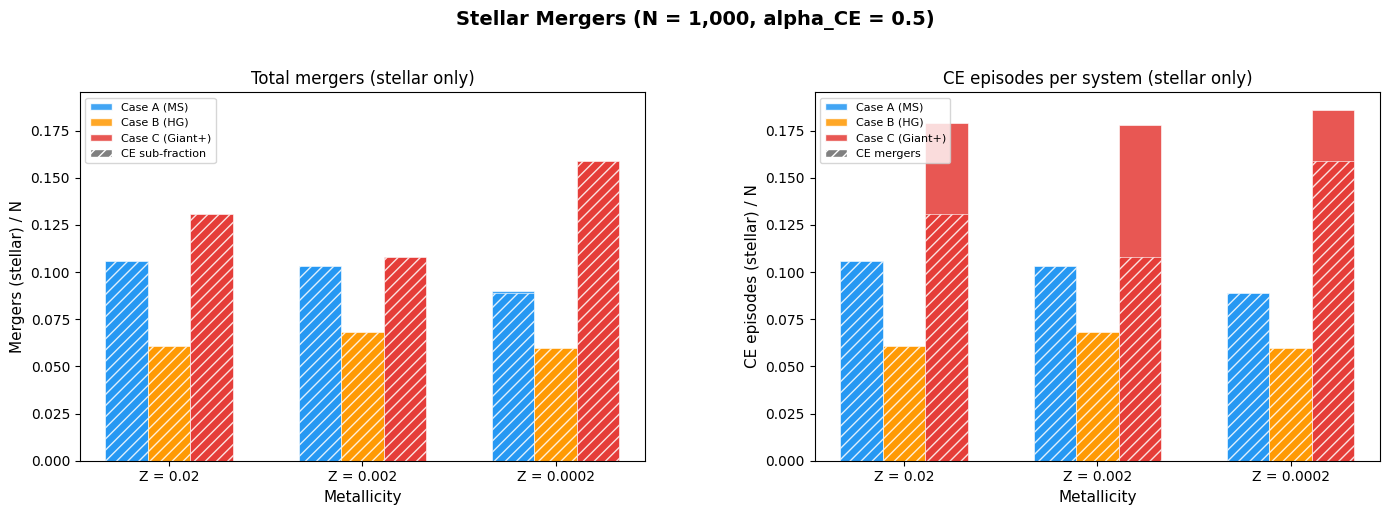

             rate_all_merger_c  rate_ce_merger_c
metallicity                                     
0.0200                   0.100             0.100
0.0020                   0.095             0.095
0.0002                   0.141             0.141


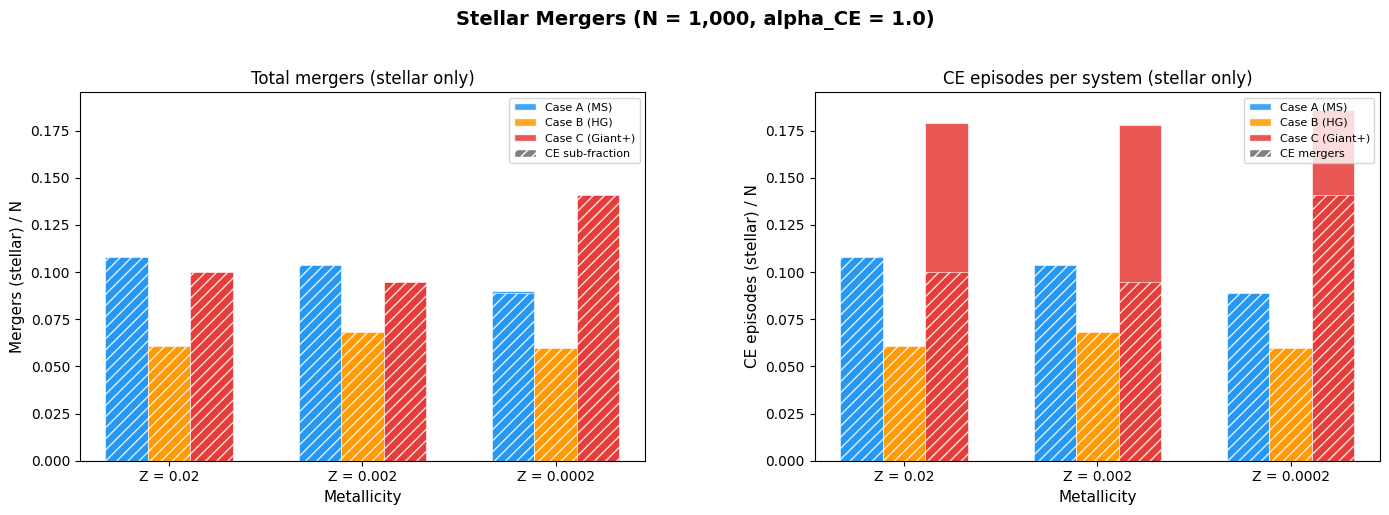

             rate_all_merger_c  rate_ce_merger_c
metallicity                                     
0.0200                   0.061             0.061
0.0020                   0.073             0.072
0.0002                   0.106             0.106


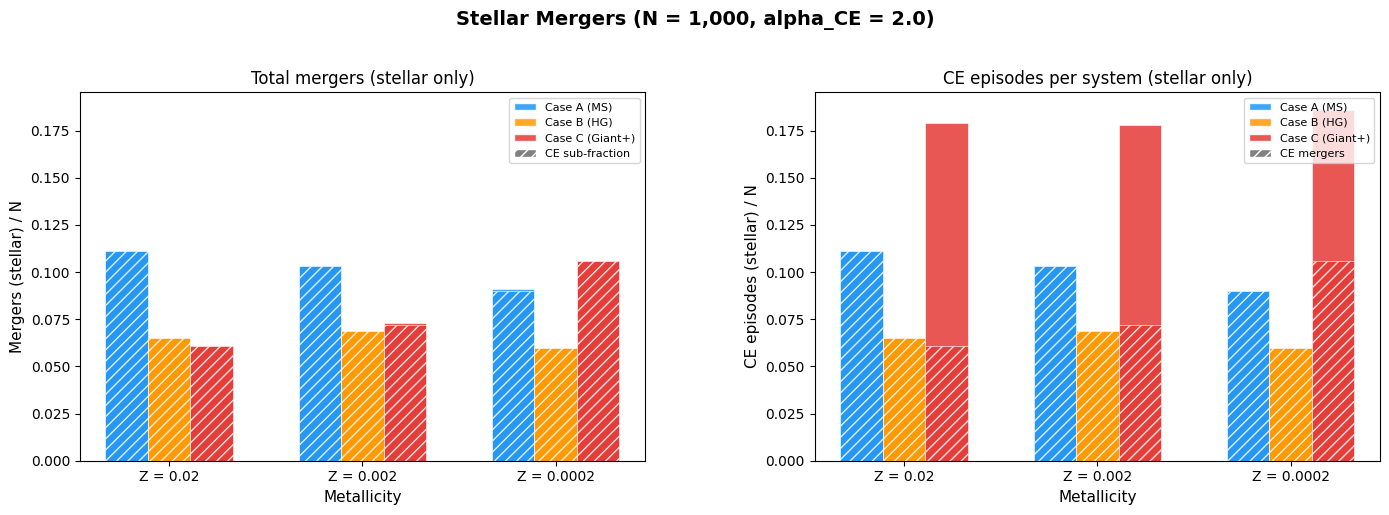

In [12]:
for alpha_ce in ALPHA_VALUES:
    for n in N_VALUES:

        sub = (
            results_df[
                (results_df["n_systems"] == n) &
                (results_df["alpha_ce"]  == alpha_ce)
            ]
            .set_index("metallicity")
            .reindex(METALLICITIES)
        )

        print(sub[["rate_all_merger_c", "rate_ce_merger_c"]])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f"Stellar Mergers (N = {n:,}, alpha_CE = {alpha_ce})",
            fontsize=14, fontweight="bold", y=1.02
        )

        case_legend = [
            Patch(facecolor=c, edgecolor="white", label=l, alpha=ALPHA_FILL)
            for l, c in CASE_COLORS.items()
        ]

        # --- Plot 1 (left): Total mergers / N, CE sub-fraction hatched ---
        ax = axes[0]
        _add_case_bars(
            ax, sub,
            col_base = ["rate_all_merger_a", "rate_all_merger_b", "rate_all_merger_c"],
            col_ce   = ["rate_ce_merger_a",  "rate_ce_merger_b",  "rate_ce_merger_c"],
            colors   = CASE_COLORS,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(ZLABELS, fontsize=10)
        ax.set_xlabel("Metallicity", fontsize=11)
        ax.set_ylabel("Mergers (stellar) / N", fontsize=11)
        ax.set_title("Total mergers (stellar only)", fontsize=12)
        ax.legend(handles=case_legend + [
            Patch(facecolor="grey", hatch=HATCH, edgecolor="white", label="CE sub-fraction")
        ], fontsize=8)

        # --- Plot 2 (right): CE episodes / N, CE merger sub-fraction hatched ---
        ax = axes[1]
        _add_case_bars(
            ax, sub,
            col_base = ["rate_total_ce_a", "rate_total_ce_b", "rate_total_ce_c"],
            col_ce   = ["rate_ce_merger_a", "rate_ce_merger_b", "rate_ce_merger_c"],
            colors   = CASE_COLORS,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(ZLABELS, fontsize=10)
        ax.set_xlabel("Metallicity", fontsize=11)
        ax.set_ylabel("CE episodes (stellar) / N", fontsize=11)
        ax.set_title("CE episodes per system (stellar only)", fontsize=12)
        ax.legend(handles=case_legend + [
            Patch(facecolor="grey", hatch=HATCH, edgecolor="white", label="CE mergers")
        ], fontsize=8)

        ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
        axes[0].set_ylim(0, ymax)
        axes[1].set_ylim(0, ymax)

        plt.tight_layout()
        plt.subplots_adjust(wspace=0.3)
        plt.savefig(f"mergers_n{n}_alpha{alpha_ce}.png", dpi=150, bbox_inches="tight")
        plt.show()